In [1]:
# import os
# import json
# with open('kaggle.json', 'r', encoding='utf-8') as file:
#     username_key = json.load(file)

# os.environ['KAGGLE_USERNAME'] = username_key['username']
# os.environ['KAGGLE_KEY'] = username_key['key']

In [1]:
!kaggle datasets download debasisdotcom/name-entity-recognition-ner-dataset

Dataset URL: https://www.kaggle.com/datasets/debasisdotcom/name-entity-recognition-ner-dataset
License(s): other
100%|██████████████████████████████████████| 3.17M/3.17M [00:00<00:00, 4.38MB/s]



In [2]:
!unzip name-entity-recognition-ner-dataset.zip

Archive:  name-entity-recognition-ner-dataset.zip
  inflating: NER dataset.csv         


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import transformers
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
import torch
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import torch.nn as nn
from sklearn.metrics import accuracy_score
import pickle as pkl
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import string
from collections import defaultdict, deque
from transformers import AutoTokenizer, AutoModel
from transformers import AutoModelForCausalLM, AutoTokenizer
import json
from tqdm.auto import tqdm
from ast import literal_eval
import json
import re

# Подготовка датасета

In [4]:
data = pd.read_csv("NER dataset.csv", encoding="latin-1")
data.head()

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,NaN,of,IN,O
2,NaN,demonstrators,NNS,O
3,NaN,have,VBP,O
4,NaN,marched,VBN,O


In [5]:
data['Tag'].unique()

array(['O', 'B-geo', 'B-gpe', 'B-per', 'I-geo', 'B-org', 'I-org', 'B-tim',
       'B-art', 'I-art', 'I-per', 'I-gpe', 'I-tim', 'B-nat', 'B-eve',
       'I-eve', 'I-nat'], dtype=object)

In [6]:
data['Sentence #'].unique().shape

(47960,)

In [7]:
data["Sentence #"] = data["Sentence #"].fillna(method='ffill')
le = LabelEncoder().fit(data['Tag'])
data['Tag'] = le.transform(data['Tag'])
pkl.dump(le, open('labelenc.pkl', 'wb'))
data.head()

/tmp/ipykernel_55/3770486824.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data["Sentence #"] = data["Sentence #"].fillna(method='ffill')


,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,16
1,Sentence: 1,of,IN,16
2,Sentence: 1,demonstrators,NNS,16
3,Sentence: 1,have,VBP,16
4,Sentence: 1,marched,VBN,16


In [8]:
data_gr = data.groupby("Sentence #").agg({'Word': list, 'POS':list, 'Tag':list})
data_gr['Word'] = data_gr['Word'].map(lambda x: list(map(str, x)))
data_gr.head()

,Word,POS,Tag
Sentence #,,,
Sentence: 1,"[Thousands, of, demonstrators, have, marched, ...","[NNS, IN, NNS, VBP, VBN, IN, NNP, TO, VB, DT, ...","[16, 16, 16, 16, 16, 16, 2, 16, 16, 16, 16, 16..."
Sentence: 10,"[Iranian, officials, say, they, expect, to, ge...","[JJ, NNS, VBP, PRP, VBP, TO, VB, NN, TO, JJ, J...","[3, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16..."
Sentence: 100,"[Helicopter, gunships, Saturday, pounded, mili...","[NN, NNS, NNP, VBD, JJ, NNS, IN, DT, NNP, JJ, ...","[16, 16, 7, 16, 16, 16, 16, 16, 2, 16, 16, 16,..."
Sentence: 1000,"[They, left, after, a, tense, hour-long, stand...","[PRP, VBD, IN, DT, NN, JJ, NN, IN, NN, NNS, .]","[16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16]"
Sentence: 10000,"[U.N., relief, coordinator, Jan, Egeland, said...","[NNP, NN, NN, NNP, NNP, VBD, NNP, ,, NNP, ,, J...","[2, 16, 16, 6, 14, 16, 7, 16, 2, 16, 3, 16, 3,..."


# Подсчет статистики

In [11]:
C = 2
OTHER_IDX = le.transform(["O"])[0]
LAMBDA_1, LAMBDA_2 = 0.5, 0.5
W_E, W_C, W_O = 1, 1, 0.1
M = 1
K = 2

train_sent, val_sent, train_tag, val_tag = train_test_split(data_gr['Word'], data_gr['Tag'], test_size=0.01, random_state=10)
train_tag_without_O = train_tag.apply(lambda x: [i for i in x if int(i)!=16])
val_tag_without_O = val_tag.apply(lambda x: [i for i in x if int(i)!=16])

In [11]:
# C_adj = 2
# tokens = train_sent.iloc[0]
# tags = train_tag.iloc[0]

# token_roles = {}
# context_span = defaultdict(list)
# entity_span = defaultdict(list)
# other_span = defaultdict(list)

# l = 0
# q_entities = deque()
# is_context = set()
# is_other = set()
# for r in range(len(tokens)):
#     if tokens[r] not in token_roles:
#         token_roles[tokens[r]] = [0, 0, 0] # entity, context, other
#     if tags[r] != OTHER_IDX:
#         token_roles[tokens[r]][0] += 1
#         q_entities.append(r)
#     if r >= C_adj:
#         center_id = r - C_adj
#         if tags[center_id] != OTHER_IDX:
#             span = deque([tokens[center_id]])
#             # жестко костылим спан для энтити
#             if tags[center_id+1] == OTHER_IDX:
#                 span.append(tokens[center_id+1])
#                 if tags[center_id+2] == OTHER_IDX:
#                     span.append(tokens[center_id+2])
#             if center_id - 1 > l and tags[center_id-1] == OTHER_IDX:
#                 span.appendleft(tokens[center_id-1])
#                 if center_id - 2 == l and tags[center_id-2] == OTHER_IDX:
#                     span.appendleft(tokens[center_id-2])
#             entity_span[tokens[center_id]].append(list(span))
#         else:
#             span = deque([tokens[center_id]])
#             span.append(tokens[center_id+1])
#             span.append(tokens[center_id+2])
#             if center_id - 1 > l:
#                 span.appendleft(tokens[center_id-1])
#                 if center_id - 2 == l:
#                     span.appendleft(tokens[center_id-2])
#             if center_id in is_context or tags[center_id + 1] != OTHER_IDX or tags[center_id + 2] != OTHER_IDX:
#                 context_span[tokens[center_id]].append(list(span))
#             else:
#                 other_span[tokens[center_id]].append(list(span))

#     if r - C_adj*2 >= 0:
#         if tags[l] != OTHER_IDX:
#             if q_entities and abs(q_entities[0] - C_adj) <= 2:
#                 token_roles[tokens[l]][1] += 1
#                 is_context.add(tags[l])
#             else:
#                 token_roles[tokens[l]][2] += 1
#                 is_other.add(tags[l])
#         if q_entities and q_entities[0] == l:
#             q_entities.popleft()
#         l += 1

token_roles = defaultdict(lambda: [0, 0, 0]) # entity, context, other
context_span = defaultdict(list)
entity_span = defaultdict(list)
other_span = defaultdict(list)

for row_idx in range(len(train_sent)):
    tokens = train_sent.iloc[row_idx]
    tags = train_tag.iloc[row_idx]
    roles = ["Other"] * len(tokens)
    for i, tag in enumerate(tags):
        if tag != OTHER_IDX:
            roles[i] = "Entity"
    for i, role in enumerate(roles):
        if role == "Entity":
            left = max(0, i - C)
            right = min(len(tokens), i + C + 1)

            for j in range(left, right):
                if roles[j] == "Other":
                    roles[j] = "Context"


    for i, token in enumerate(tokens):
        role = roles[i]

        left = max(0, i - C)
        right = min(len(tokens), i + C + 1)

        if role == "Entity":
            token_roles[token][0] += 1

            span_tokens = []
            for j in range(left, right):
                if j == i:
                    span_tokens.append(tokens[j])
                elif tags[j] == OTHER_IDX:
                    span_tokens.append(tokens[j])

            entity_span[token].append(" ".join(span_tokens))

        elif role == "Context":
            token_roles[token][1] += 1
            span_tokens = tokens[left:right]
            context_span[token].append(" ".join(span_tokens))

        elif role == "Other":
            token_roles[token][2] += 1
            span_tokens = tokens[left:right]
            other_span[token].append(" ".join(span_tokens))

In [12]:
print("Роли токенов в предложении:", list(zip(tokens, roles)))

Роли токенов в предложении: [('The', 'Context'), ('U.S.', 'Entity'), ('diplomat', 'Context'), ('is', 'Context'), ('to', 'Other'), ('address', 'Context'), ('an', 'Context'), ('Israeli', 'Entity'), ('think-tank', 'Context'), ('later', 'Context'), ('Sunday', 'Entity'), ('before', 'Context'), ('meeting', 'Context'), ('with', 'Context'), ('Prime', 'Entity'), ('Minister', 'Context'), ('Ariel', 'Entity'), ('Sharon', 'Entity'), ('.', 'Context')]


# Ретривал

In [13]:
class embedding_model:
    model_name = "intfloat/multilingual-e5-small"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
device = "cuda" if torch.cuda.is_available() else "cpu"
embedding_model.model.to(device)
print(embedding_model.model.device)

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


cuda:0


In [14]:
def get_words_embeddings(words):
    inputs = embedding_model.tokenizer(words, is_split_into_words=True, return_tensors="pt")
    with torch.no_grad():
        inputs = inputs.to(embedding_model.model.device)
        outputs = embedding_model.model(**inputs)
    hidden_states = outputs.last_hidden_state[0]
    word_ids = inputs.word_ids()
    word_embeddings = []

    for word_idx in range(len(words)):
        sub_token_indices = [i for i, w_id in enumerate(word_ids) if w_id == word_idx]
        sub_token_vecs = hidden_states[sub_token_indices]

        word_emb = sub_token_vecs.mean(dim=0)
        word_embeddings.append(word_emb)
    return word_embeddings

def compute_w(t, w_e, w_c, w_o):
    stats = np.array(token_roles[t])
    wei = np.array([w_e, w_c, w_o])
    if sum(stats) == 0:
        return 1
    return (stats/sum(stats)) @ wei

def get_sentence_embedding(word_embeddings, weights):
    sentence_embedding = torch.zeros_like(word_embeddings[0])
    for w_emb, weight in zip(word_embeddings, weights):
        sentence_embedding += w_emb * weight
    return sentence_embedding

train_embeddings_list = []
train_token_sets = []

unique_tokens = list(set(train_sent.explode().tolist()))
batch_size = 128
tokens_embeddings = []
for i in range(0, len(unique_tokens)//batch_size+1):
    i_high = min(i+batch_size, len(unique_tokens))
    batch = unique_tokens[i:i_high]
    tokens_embeddings.extend(get_words_embeddings(batch))
token2embedding = {token : embedding for token, embedding in zip(unique_tokens, tokens_embeddings)}

for s_i in tqdm(train_sent):
    i_token_weights = [compute_w(tok, W_E, W_C, W_O) for tok in s_i]

    s_i_word_embeddings = [token2embedding[token] for token in s_i]

    s_i_embedding = get_sentence_embedding(s_i_word_embeddings, i_token_weights)

    train_embeddings_list.append(s_i_embedding)
    train_token_sets.append(set(s_i))

train_embeddings_matrix = torch.stack(train_embeddings_list)

  0%|          | 0/47479 [00:00<?, ?it/s]

In [15]:
def retrieval(s_t, s_i, lambda_1, lambda_2, w_e, w_c, w_o):
    s_token = 0
    s_i_tokens = set(s_i)

    t_token_weights = [compute_w(tok, w_e, w_c, w_o) for tok in s_t]
    i_token_weights = [compute_w(tok, w_e, w_c, w_o) for tok in s_i]

    for i, token in enumerate(s_t):
        s_token += (token in s_i_tokens) * t_token_weights[i]

    s_t_embedding = get_sentence_embedding(s_t_word_embeddings, t_token_weights)
    s_i_embedding = get_sentence_embedding(s_i_word_embeddings, i_token_weights)
    s_embed = torch.cosine_similarity(s_t_embedding.unsqueeze(0), s_i_embedding.unsqueeze(0))
    return lambda_1*s_token + lambda_2*s_embed.item()

# Прогон модели с ретривалом

## Подбор топ 3 предложений для каждого тестового примера

In [16]:
named_entities_types = ', '.join(set([f'"{e_class[2:].upper()}"' for e_class in le.classes_ if e_class != "O"]))
Prompt = 'Here is the JSON template for named entity recognition:\n'\
        '{"named entities": [{"name": "ent_name_1", "type": "ent_type_1"}, ..., '\
        '{"name": "ent_name_n", "type": "ent_type_n"}]}\n'\
        'Please identify the four types of named entities: ' \
          f'{named_entities_types}' \
        ', following the JSON template' \
          'listed above, and output the JSON object.' \
        ' If no named entities identified, output {"' \
        'named entities": []}.\n\n'

def get_prompt(test_sentence, topk=3, OTHER_IDX=16):
    t_token_weights = [compute_w(tok, W_E, W_C, W_O) for tok in test_sentence]
    s_t_word_embeddings = get_words_embeddings(test_sentence)
    s_t_embedding = get_sentence_embedding(s_t_word_embeddings, t_token_weights)

    s_embed_scores = torch.cosine_similarity(s_t_embedding.unsqueeze(0), train_embeddings_matrix)

    s_token_scores = []
    for train_set in train_token_sets:
        score = sum(w for tok, w in zip(test_sentence, t_token_weights) if tok in train_set)
        s_token_scores.append(score)

    s_token_scores = torch.tensor(s_token_scores, device=s_embed_scores.device)

    final_scores = LAMBDA_1 * s_token_scores + LAMBDA_2 * s_embed_scores

    top_scores, top_indices = torch.topk(final_scores, k=topk)

    top_scores = top_scores.tolist()
    top_indices = top_indices.tolist()

    topk_tuples = list(zip(top_scores, top_indices))

    topk_tuples.sort(reverse=False)

    input_output = ""
    for score, idx in topk_tuples:
        input_sent = train_sent.iloc[idx]
        tag_sent = train_tag.iloc[idx]

        entities_list = []
        current_entity_words = []
        current_entity_type = None

        for word, word_tag in zip(input_sent, tag_sent):
            if word_tag != OTHER_IDX:
                tag_str = le.inverse_transform([word_tag])[0]
                prefix = tag_str[:1]
                ent_type = tag_str[2:]

                if prefix == "B":
                    if current_entity_words:
                        entities_list.append({"name": " ".join(current_entity_words), "type": current_entity_type})
                    current_entity_words = [word]
                    current_entity_type = ent_type
                elif prefix == "I" and current_entity_type == ent_type:
                    current_entity_words.append(word)
            else:
                if current_entity_words:
                    entities_list.append({"name": " ".join(current_entity_words), "type": current_entity_type})
                    current_entity_words = []
                    current_entity_type = None

        if current_entity_words:
            entities_list.append({"name": " ".join(current_entity_words), "type": current_entity_type})

        output_dict = {"named entities": entities_list}

        output_json_str = json.dumps(output_dict, ensure_ascii=False)

        input_output += f"Input: {' '.join(input_sent)}\nOutput: {output_json_str}\n\n"

    final_prompt = Prompt + input_output + f"Input: {' '.join(test_sentence)}\nOutput: "

    return final_prompt

In [17]:
print(get_prompt(val_sent.iloc[0]))

Here is the JSON template for named entity recognition:
{"named entities": [{"name": "ent_name_1", "type": "ent_type_1"}, ..., {"name": "ent_name_n", "type": "ent_type_n"}]}
Please identify the four types of named entities: "PER", "EVE", "ART", "ORG", "GEO", "TIM", "GPE", "NAT", following the JSON templatelisted above, and output the JSON object. If no named entities identified, output {"named entities": []}.

Input: U.S. and Russian officials say they seized a metric ton of heroin from four clandestine laboratories earlier this week in Nangarhar province , near the border with Pakistan .
Output: {"named entities": [{"name": "U.S.", "type": "geo"}, {"name": "Russian", "type": "gpe"}, {"name": "Nangarhar", "type": "geo"}, {"name": "Pakistan", "type": "geo"}]}

Input: Supporters of the former chief of the giant Russian oil firm Yukos say authorities had rushed through the appeal to prevent Khodorkovsky from running in a December parliamentary by-election .
Output: {"named entities": [{"n

In [18]:
model_name = "Qwen/Qwen2.5-7B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Some parameters are on the meta device because they were offloaded to the cpu.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [19]:
prompt = get_prompt(val_sent.iloc[0])
messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

with torch.no_grad():
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=512
    )
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

In [20]:
print(response)

{"named entities": [{"name": "Kyrgyzstan", "type": "geo"}, {"name": "Kurdish", "type": "nat"}, {"name": "Russian", "type": "gpe"}]}


In [21]:
responses = []
for i in range(len(val_sent)):
    prompt = get_prompt(val_sent.iloc[i])
    messages = [
        {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=512
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    responses.append(response)
    print(" ".join(val_sent.iloc[i]))
    print(response)
    print()

Officials in Kyrgyzstan say they have detained about 50 people after hundreds of looters tore through a Kurdish village to protest the rape of a four year-old Russian girl .
{"named entities": [{"name": "Kyrgyzstan", "type": "geo"}, {"name": "Kurdish", "type": "nat"}, {"name": "Russian", "type": "gpe"}]}

Her expected appearance follows a Serbian court Tuesday suspending an arrest warrant for her on charges of abuse of power .
{"named entities": [{"name": "Serbian", "type": "gpe"}, {"name": "Tuesday", "type": "tim"}]}

The Security Council has approved a U.N. mission for Darfur to take over from an under-funded A.U. mission .
{"named entities": [{"name": "Security Council", "type": "org"}, {"name": "U.N.", "type": "org"}, {"name": "Darfur", "type": "gpe"}, {"name": "A.U.", "type": "org"}]}

But they say developing nations are weathering this economic down-turn better than they have similar incidents in the past because they are better integrated into the world economy .
{"named entitie

In [22]:
with open('responses.json', 'w') as f:
    json.dump(responses, f)

In [23]:

TP = 0
FP = 0
FN = 0

for i, (input_sent, tag_sent, raw_response) in enumerate(zip(val_sent, val_tag, responses)):
    predicted_set = set()
    json_match = re.search(r'\{.*?"named\s*entities".*?\]\s*\}', raw_response, re.DOTALL | re.IGNORECASE)
    
    if json_match:
        try:
            parsed_json = json.loads(json_match.group(0))
            
            entities = parsed_json.get("named entities", parsed_json.get("named_entities", []))
            
            for ent in entities:
                name = str(ent.get("name", "")).strip()
                ent_type = str(ent.get("type", "")).strip().lower()
                
                if name and ent_type:
                    predicted_set.add((name, ent_type))
                    
        except json.JSONDecodeError:
            pass
    true_set = set()
    current_entity_words = []
    current_entity_type = None

    for word, word_tag in zip(input_sent, tag_sent):
        if word_tag != OTHER_IDX:
            tag_str = le.inverse_transform([word_tag])[0].strip().lower() 
            
            prefix = tag_str[:1] 
            ent_type = tag_str[2:] 

            if prefix == "b":
                if current_entity_words:
                    true_set.add((" ".join(current_entity_words), current_entity_type))
                
                current_entity_words = [word]
                current_entity_type = ent_type
                
            elif prefix == "i" and current_entity_type == ent_type:
                current_entity_words.append(word)
        else:
            if current_entity_words:
                true_set.add((" ".join(current_entity_words), current_entity_type))
                current_entity_words = []
                current_entity_type = None
                
    if current_entity_words:
        true_set.add((" ".join(current_entity_words), current_entity_type))
        
    matched = predicted_set & true_set
    TP += len(matched)

    false_positives = predicted_set - true_set
    FP += len(false_positives)

    false_negatives = true_set - predicted_set
    FN += len(false_negatives)


precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0


print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Precision: 0.6249
Recall: 0.7261
F1-Score: 0.6717


In [24]:
named_entities_types = ', '.join(set([f'"{e_class[2:].upper()}"' for e_class in le.classes_ if e_class != "O"]))
Prompt = 'Here is the JSON template for named entity recognition:\n'\
        '{"named entities": [{"name": "ent_name_1", "type": "ent_type_1"}, ..., '\
        '{"name": "ent_name_n", "type": "ent_type_n"}]}\n'\
        'Please identify the four types of named entities: ' \
          f'{named_entities_types}' \
        ', following the JSON template' \
          'listed above, and output the JSON object.' \
        ' If no named entities identified, output {"' \
        'named entities": []}. You can text nothing except JSON output.\n\n'

In [19]:
model_name = "Qwen/Qwen2.5-7B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Some parameters are on the meta device because they were offloaded to the cpu.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [25]:
responses_no_r = []
for i in range(len(val_sent)):
    prompt = Prompt + "\nInput: " + " ".join(val_sent.iloc[i]) + "\nOutput:" 
    messages = [
        {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=512
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    responses_no_r.append(response)
    print(" ".join(val_sent.iloc[i]))
    print(response)
    print()

Officials in Kyrgyzstan say they have detained about 50 people after hundreds of looters tore through a Kurdish village to protest the rape of a four year-old Russian girl .
{"named entities": [{"name": "Kyrgyzstan", "type": "GPE"}, {"name": "Russian", "type": "PER"}, {"name": "Kurdish", "type": "NAT"}]}

Her expected appearance follows a Serbian court Tuesday suspending an arrest warrant for her on charges of abuse of power .
```json
{"named entities": [{"name": "Serbian court", "type": "ORG"}, {"name": "Tuesday", "type": "TIM"}]}
```

The Security Council has approved a U.N. mission for Darfur to take over from an under-funded A.U. mission .
{"named entities": [{"name": "Security Council", "type": "ORG"}, {"name": "U.N.", "type": "ORG"}, {"name": "Darfur", "type": "GEO"}, {"name": "A.U.", "type": "ORG"}]}

But they say developing nations are weathering this economic down-turn better than they have similar incidents in the past because they are better integrated into the world economy

In [26]:
with open('responses_no_r.json', 'w') as f:
    json.dump(responses_no_r, f)

In [27]:
TP = 0
FP = 0
FN = 0

for i, (input_sent, tag_sent, raw_response) in enumerate(zip(val_sent, val_tag, responses_no_r)):
    predicted_set = set()
    json_match = re.search(r'\{.*?"named\s*entities".*?\]\s*\}', raw_response, re.DOTALL | re.IGNORECASE)
    
    if json_match:
        try:
            parsed_json = json.loads(json_match.group(0))
            
            entities = parsed_json.get("named entities", parsed_json.get("named_entities", []))
            
            for ent in entities:
                name = str(ent.get("name", "")).strip()
                ent_type = str(ent.get("type", "")).strip().lower()
                
                if name and ent_type:
                    predicted_set.add((name, ent_type))
                    
        except json.JSONDecodeError:
            pass
    true_set = set()
    current_entity_words = []
    current_entity_type = None

    for word, word_tag in zip(input_sent, tag_sent):
        if word_tag != OTHER_IDX:
            tag_str = le.inverse_transform([word_tag])[0].strip().lower() 
            
            prefix = tag_str[:1] 
            ent_type = tag_str[2:] 

            if prefix == "b":
                if current_entity_words:
                    true_set.add((" ".join(current_entity_words), current_entity_type))
                
                current_entity_words = [word]
                current_entity_type = ent_type
                
            elif prefix == "i" and current_entity_type == ent_type:
                current_entity_words.append(word)
        else:
            if current_entity_words:
                true_set.add((" ".join(current_entity_words), current_entity_type))
                current_entity_words = []
                current_entity_type = None
                
    if current_entity_words:
        true_set.add((" ".join(current_entity_words), current_entity_type))
        
    matched = predicted_set & true_set
    TP += len(matched)

    false_positives = predicted_set - true_set
    FP += len(false_positives)

    false_negatives = true_set - predicted_set
    FN += len(false_negatives)


precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0


print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Precision: 0.3075
Recall: 0.3858
F1-Score: 0.3422


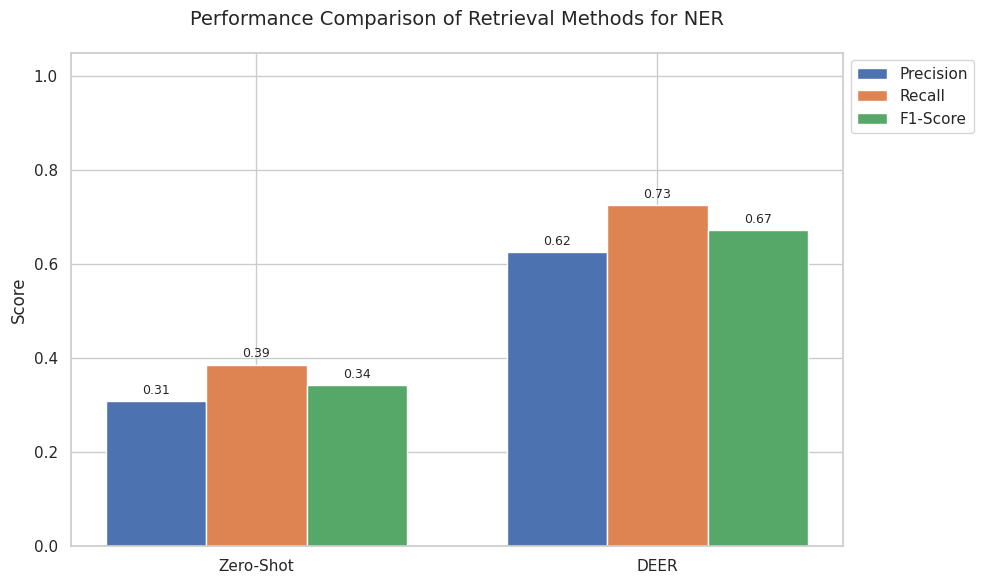

In [29]:
sns.set_theme(style="whitegrid")
methods = ['Zero-Shot', 'DEER']

precision = [precision, 0.6249]
recall = [recall, 0.7261]
f1_scores = [f1, 0.6717]

x = np.arange(len(methods))
width = 0.25 

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width, precision, width, label='Precision', color='#4C72B0')
rects2 = ax.bar(x, recall, width, label='Recall', color='#DD8452')
rects3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='#55A868')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Comparison of Retrieval Methods for NER', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

Эксперименты были проведены на P100, Qwen2.5-7B используя метод Label Guided Retrieval DEER.  
Zero-Shot выступил в качестве бейзлайна с f1 0.34  
LGR DEER f1 0.67